In [1]:
# imports & setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from datetime import datetime, timedelta
from sklearn.ensemble import RandomForestRegressor
import lightgbm as lgb
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import joblib
import json
import pickle
import warnings
warnings.filterwarnings('ignore')

In [2]:
# load data
from google.colab import drive
drive.mount("/content/drive", force_remount=True)
df = pd.read_csv("/content/drive/MyDrive/kita coba ygy/transport.3.csv")

Mounted at /content/drive


In [3]:
# eksplorasi data awal
df.info()
print(df.isna().sum())
df

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18691 entries, 0 to 18690
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   plant_id          18691 non-null  int64  
 1   year              18691 non-null  int64  
 2   month             18691 non-null  int64  
 3   subcategory_code  18691 non-null  float64
 4   supplier          18691 non-null  object 
 5   emission          18691 non-null  float64
 6   category          18691 non-null  object 
dtypes: float64(2), int64(3), object(2)
memory usage: 1022.3+ KB
plant_id            0
year                0
month               0
subcategory_code    0
supplier            0
emission            0
category            0
dtype: int64


,plant_id,year,month,subcategory_code,supplier,emission,category
0,1,2023,1,3.10,CV. PML,0.024280,transport
1,1,2023,1,3.10,PT. KP,0.003677,transport
2,1,2023,1,3.10,PT. KP,0.003677,transport
3,1,2023,1,3.10,PT. KP,0.003677,transport
4,1,2023,1,3.10,PT. KP,0.003677,transport
...,...,...,...,...,...,...,...
18686,2,2024,12,3.11,JPM,0.003852,transport
18687,2,2024,12,3.11,JPM,0.003852,transport
18688,2,2024,12,3.11,JPM,0.003852,transport
18689,2,2024,12,3.11,JPM,0.003852,transport


In [4]:
# data cleaning
df = df.fillna(0)
df = df[df['subcategory_code'].isin([3.1, 3.11])]
df = df[df['year'].isin([2023, 2024])]
df['emission'] = pd.to_numeric(df['emission'], errors='coerce')
df = df.dropna(subset=['emission'])
print(f"Jumlah baris setelah cleaning: {len(df)}")

Jumlah baris setelah cleaning: 18691


In [5]:
# agregasi bulanan per supplier dan plant
agg_df = df.groupby(['year', 'month', 'plant_id', 'supplier']).agg(
    total_emission=('emission', 'sum'),
    freq=('emission', 'count')
).reset_index()

agg_df['date'] = pd.to_datetime(agg_df['year'].astype(str) + '-' + agg_df['month'].astype(str).str.zfill(2) + '-01')
agg_df = agg_df.sort_values(['date', 'supplier']).reset_index(drop=True)
agg_df['plant_id_encoded'] = LabelEncoder().fit_transform(agg_df['plant_id'])

print(f"Jumlah sampel setelah agregasi: {len(agg_df)}")

Jumlah sampel setelah agregasi: 2983


In [6]:
# feature engineering
le = LabelEncoder()
agg_df['supplier_encoded'] = le.fit_transform(agg_df['supplier'])

for lag in [1, 2, 3]:
    agg_df[f'emission_lag_{lag}'] = agg_df.groupby('supplier')['total_emission'].shift(lag)

agg_df['emission_rolling_mean_3'] = agg_df.groupby('supplier')['total_emission'].transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
agg_df['emission_rolling_std_3'] = agg_df.groupby('supplier')['total_emission'].transform(lambda x: x.shift(1).rolling(3, min_periods=1).std())

for lag in [1, 2]:
    agg_df[f'freq_lag_{lag}'] = agg_df.groupby('supplier')['freq'].shift(lag)

agg_df = pd.get_dummies(agg_df, columns=['month'], prefix='month', dtype=int)
agg_df = agg_df.dropna().reset_index(drop=True)

print(f"Jumlah sampel setelah feature engineering: {len(agg_df)}")

Jumlah sampel setelah feature engineering: 2208


In [7]:
# definisi fitur, target, dan train-test split
feature_cols = [col for col in agg_df.columns if col not in
                ['total_emission', 'year', 'date', 'supplier', 'supplier_encoded', 'plant_id', 'plant_id_encoded']] + ['supplier_encoded', 'plant_id_encoded']

X = agg_df[feature_cols]
y = agg_df['total_emission']

THRESHOLD = y.quantile(0.25)
print(f"Threshold segmentasi: {THRESHOLD:.4f}")

tscv = TimeSeriesSplit(n_splits=5)
for train_idx, test_idx in tscv.split(X):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")

Threshold segmentasi: 0.0236
Train size: 1840, Test size: 368


In [8]:
# fungsi evaluasi metrik
def metrics(y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mask = np.abs(y_true) > 0.01
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100 if mask.sum() > 0 else float('nan')
    return mae, rmse, r2, mape

In [9]:
# cross validation semua model
fold_scores = {
    'xgb': [], 'xgb_log': [], 'xgb_seg': [],
    'rf': [],  'rf_log': [],  'rf_seg': [],
    'lgb': [], 'lgb_log': [], 'lgb_seg': [],
}

default_lgb_params = dict(n_estimators=300, learning_rate=0.05, num_leaves=31, min_child_samples=5, random_state=42, verbose=-1)

for train_idx, test_idx in TimeSeriesSplit(n_splits=5).split(X):
    X_tr, X_val = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[test_idx]

    mask_tr_small  = y_tr <= THRESHOLD
    mask_tr_large  = ~mask_tr_small
    mask_val_small = y_val <= THRESHOLD
    mask_val_large = ~mask_val_small

    m = xgb.XGBRegressor(n_estimators=300, max_depth=5, learning_rate=0.05, subsample=0.8, random_state=42)
    m.fit(X_tr, y_tr)
    fold_scores['xgb'].append(np.sqrt(mean_squared_error(y_val, m.predict(X_val))))

    m = xgb.XGBRegressor(n_estimators=300, max_depth=5, learning_rate=0.05, subsample=0.8, random_state=42)
    m.fit(X_tr, np.log1p(y_tr))
    fold_scores['xgb_log'].append(np.sqrt(mean_squared_error(y_val, np.expm1(m.predict(X_val)))))

    ms = xgb.XGBRegressor(n_estimators=300, max_depth=5, learning_rate=0.05, subsample=0.8, random_state=42)
    ml = xgb.XGBRegressor(n_estimators=300, max_depth=5, learning_rate=0.05, subsample=0.8, random_state=42)
    if mask_tr_small.any(): ms.fit(X_tr[mask_tr_small], y_tr[mask_tr_small])
    if mask_tr_large.any(): ml.fit(X_tr[mask_tr_large], np.log1p(y_tr[mask_tr_large]))
    pred_seg = np.where(mask_val_small, ms.predict(X_val), np.expm1(ml.predict(X_val)))
    fold_scores['xgb_seg'].append(np.sqrt(mean_squared_error(y_val, pred_seg)))

    m = RandomForestRegressor(n_estimators=300, max_depth=10, random_state=42)
    m.fit(X_tr, y_tr)
    fold_scores['rf'].append(np.sqrt(mean_squared_error(y_val, m.predict(X_val))))

    m = RandomForestRegressor(n_estimators=300, max_depth=10, random_state=42)
    m.fit(X_tr, np.log1p(y_tr))
    fold_scores['rf_log'].append(np.sqrt(mean_squared_error(y_val, np.expm1(m.predict(X_val)))))

    ms = RandomForestRegressor(n_estimators=300, max_depth=10, random_state=42)
    ml = RandomForestRegressor(n_estimators=300, max_depth=10, random_state=42)
    if mask_tr_small.any(): ms.fit(X_tr[mask_tr_small], y_tr[mask_tr_small])
    if mask_tr_large.any(): ml.fit(X_tr[mask_tr_large], np.log1p(y_tr[mask_tr_large]))
    pred_seg = np.where(mask_val_small, ms.predict(X_val), np.expm1(ml.predict(X_val)))
    fold_scores['rf_seg'].append(np.sqrt(mean_squared_error(y_val, pred_seg)))

    m = lgb.LGBMRegressor(**default_lgb_params)
    m.fit(X_tr, y_tr)
    fold_scores['lgb'].append(np.sqrt(mean_squared_error(y_val, m.predict(X_val))))

    m = lgb.LGBMRegressor(**default_lgb_params)
    m.fit(X_tr, np.log1p(y_tr))
    fold_scores['lgb_log'].append(np.sqrt(mean_squared_error(y_val, np.expm1(m.predict(X_val)))))

    ms = lgb.LGBMRegressor(**default_lgb_params)
    ml = lgb.LGBMRegressor(**default_lgb_params)
    if mask_tr_small.any(): ms.fit(X_tr[mask_tr_small], y_tr[mask_tr_small])
    if mask_tr_large.any(): ml.fit(X_tr[mask_tr_large], np.log1p(y_tr[mask_tr_large]))
    pred_seg = np.where(mask_val_small, ms.predict(X_val), np.expm1(ml.predict(X_val)))
    fold_scores['lgb_seg'].append(np.sqrt(mean_squared_error(y_val, pred_seg)))

print(f"{'Model':<25} {'CV RMSE Mean':>14} {'± Std':>10}")
print("-" * 52)
for name, scores in fold_scores.items():
    print(f"{name:<25} {np.mean(scores):>14.4f} {np.std(scores):>10.4f}")

best_cv_model = min(fold_scores, key=lambda k: np.mean(fold_scores[k]))
print(f"\n✅ Best model by CV: {best_cv_model} | RMSE={np.mean(fold_scores[best_cv_model]):.4f}")

Model                       CV RMSE Mean      ± Std
----------------------------------------------------
xgb                               0.4542     0.1331
xgb_log                           0.3724     0.0785
xgb_seg                           0.3727     0.0804
rf                                0.4402     0.0847
rf_log                            0.4036     0.0789
rf_seg                            0.4099     0.0834
lgb                               0.4520     0.0978
lgb_log                           0.4087     0.1103
lgb_seg                           0.4024     0.1024

✅ Best model by CV: xgb_log | RMSE=0.3724


In [10]:
# hyperparameter tuning dengan optuna (hanya pada data training)
!pip install optuna -q
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators', 100, 600),
        'max_depth'        : trial.suggest_int('max_depth', 3, 10),
        'learning_rate'    : trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'num_leaves'       : trial.suggest_int('num_leaves', 20, 80),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 30),
        'subsample'        : trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'random_state'     : 42,
        'verbose'          : -1,
    }
    inner_cv = TimeSeriesSplit(n_splits=3)
    scores = []
    for tr_idx, val_idx in inner_cv.split(X_train):
        X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]
        m = lgb.LGBMRegressor(**params)
        m.fit(X_tr, np.log1p(y_tr))
        scores.append(np.sqrt(mean_squared_error(y_val, np.expm1(m.predict(X_val)))))
    return np.mean(scores)

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

best_lgb_params = study.best_params
print("Best CV RMSE (LightGBM):", study.best_value)
print("Best params:", best_lgb_params)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 12.8 MB/s eta 0:00:00


  0%|          | 0/50 [00:00<?, ?it/s]

Best CV RMSE (LightGBM): 0.410886316295947
Best params: {'n_estimators': 509, 'max_depth': 7, 'learning_rate': 0.03876892506526752, 'num_leaves': 62, 'min_child_samples': 7, 'subsample': 0.9955626631444169, 'colsample_bytree': 0.6115490231141065}


In [11]:
# training final semua model
mask_train_small = y_train <= THRESHOLD
mask_train_large = ~mask_train_small
mask_test_small  = y_test <= THRESHOLD
mask_test_large  = ~mask_test_small

xgb_model = xgb.XGBRegressor(n_estimators=300, max_depth=5, learning_rate=0.05, subsample=0.8, random_state=42)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

xgb_log = xgb.XGBRegressor(n_estimators=300, max_depth=5, learning_rate=0.05, subsample=0.8, random_state=42)
xgb_log.fit(X_train, np.log1p(y_train))
y_pred_xgb_log = np.expm1(xgb_log.predict(X_test))

xgb_small = xgb.XGBRegressor(n_estimators=300, max_depth=5, learning_rate=0.05, subsample=0.8, random_state=42)
xgb_large = xgb.XGBRegressor(n_estimators=300, max_depth=5, learning_rate=0.05, subsample=0.8, random_state=42)
xgb_small.fit(X_train[mask_train_small], y_train[mask_train_small])
xgb_large.fit(X_train[mask_train_large], np.log1p(y_train[mask_train_large]))
y_pred_xgb_seg = np.where(mask_test_small, xgb_small.predict(X_test), np.expm1(xgb_large.predict(X_test)))

rf_model = RandomForestRegressor(n_estimators=300, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

rf_log = RandomForestRegressor(n_estimators=300, max_depth=10, random_state=42)
rf_log.fit(X_train, np.log1p(y_train))
y_pred_rf_log = np.expm1(rf_log.predict(X_test))

rf_small = RandomForestRegressor(n_estimators=300, max_depth=10, random_state=42)
rf_large = RandomForestRegressor(n_estimators=300, max_depth=10, random_state=42)
rf_small.fit(X_train[mask_train_small], y_train[mask_train_small])
rf_large.fit(X_train[mask_train_large], np.log1p(y_train[mask_train_large]))
y_pred_rf_seg = np.where(mask_test_small, rf_small.predict(X_test), np.expm1(rf_large.predict(X_test)))

lgb_model = lgb.LGBMRegressor(n_estimators=300, learning_rate=0.05, num_leaves=31, min_child_samples=5, random_state=42, verbose=-1)
lgb_model.fit(X_train, y_train)
y_pred_lgb = lgb_model.predict(X_test)

lgb_log = lgb.LGBMRegressor(**best_lgb_params, random_state=42, verbose=-1)
lgb_log.fit(X_train, np.log1p(y_train))
y_pred_log = np.expm1(lgb_log.predict(X_test))

lgb_small = lgb.LGBMRegressor(**best_lgb_params, random_state=42, verbose=-1)
lgb_large = lgb.LGBMRegressor(**best_lgb_params, random_state=42, verbose=-1)
lgb_small.fit(X_train[mask_train_small], y_train[mask_train_small])
lgb_large.fit(X_train[mask_train_large], np.log1p(y_train[mask_train_large]))
y_pred_segmented = np.where(mask_test_small, lgb_small.predict(X_test), np.expm1(lgb_large.predict(X_test)))

print("Training selesai.")

Training selesai.


In [12]:
# evaluasi metrik semua model pada test set
mae_xgb,     rmse_xgb,     r2_xgb,     mape_xgb     = metrics(y_test, y_pred_xgb)
mae_rf,      rmse_rf,      r2_rf,      mape_rf      = metrics(y_test, y_pred_rf)
mae_lgb,     rmse_lgb,     r2_lgb,     mape_lgb     = metrics(y_test, y_pred_lgb)
mae_xgb_log, rmse_xgb_log, r2_xgb_log, mape_xgb_log = metrics(y_test, y_pred_xgb_log)
mae_rf_log,  rmse_rf_log,  r2_rf_log,  mape_rf_log  = metrics(y_test, y_pred_rf_log)
mae_log,     rmse_log,     r2_log,     mape_log     = metrics(y_test, y_pred_log)
mae_xgb_seg, rmse_xgb_seg, r2_xgb_seg, mape_xgb_seg = metrics(y_test, y_pred_xgb_seg)
mae_rf_seg,  rmse_rf_seg,  r2_rf_seg,  mape_rf_seg  = metrics(y_test, y_pred_rf_seg)
mae_seg,     rmse_seg,     r2_seg,     mape_seg     = metrics(y_test, y_pred_segmented)

print(f"{'Model':<30} {'MAE':>8} {'MAPE':>10} {'RMSE':>8} {'R²':>8}")
print("-" * 68)
print(f"{'XGBoost (baseline)':<30} {mae_xgb:>8.4f} {mape_xgb:>9.2f}% {rmse_xgb:>8.4f} {r2_xgb:>8.4f}")
print(f"{'XGBoost + Log':<30} {mae_xgb_log:>8.4f} {mape_xgb_log:>9.2f}% {rmse_xgb_log:>8.4f} {r2_xgb_log:>8.4f}")
print(f"{'XGBoost + Segmented':<30} {mae_xgb_seg:>8.4f} {mape_xgb_seg:>9.2f}% {rmse_xgb_seg:>8.4f} {r2_xgb_seg:>8.4f}")
print("-" * 68)
print(f"{'Random Forest (baseline)':<30} {mae_rf:>8.4f} {mape_rf:>9.2f}% {rmse_rf:>8.4f} {r2_rf:>8.4f}")
print(f"{'Random Forest + Log':<30} {mae_rf_log:>8.4f} {mape_rf_log:>9.2f}% {rmse_rf_log:>8.4f} {r2_rf_log:>8.4f}")
print(f"{'Random Forest + Segmented':<30} {mae_rf_seg:>8.4f} {mape_rf_seg:>9.2f}% {rmse_rf_seg:>8.4f} {r2_rf_seg:>8.4f}")
print("-" * 68)
print(f"{'LightGBM (baseline)':<30} {mae_lgb:>8.4f} {mape_lgb:>9.2f}% {rmse_lgb:>8.4f} {r2_lgb:>8.4f}")
print(f"{'LightGBM + Log':<30} {mae_log:>8.4f} {mape_log:>9.2f}% {rmse_log:>8.4f} {r2_log:>8.4f}")
print(f"{'LightGBM + Segmented':<30} {mae_seg:>8.4f} {mape_seg:>9.2f}% {rmse_seg:>8.4f} {r2_seg:>8.4f}")
print("-" * 68)

best_model = min([
    ('XGBoost Segmented',       rmse_xgb_seg, r2_xgb_seg),
    ('Random Forest Segmented', rmse_rf_seg,  r2_rf_seg),
    ('LightGBM Segmented',      rmse_seg,     r2_seg),
    ('XGBoost Log',             rmse_xgb_log, r2_xgb_log),
    ('Random Forest Log',       rmse_rf_log,  r2_rf_log),
    ('LightGBM Log',            rmse_log,     r2_log),
], key=lambda x: x[1])

print(f"\n✅ Model terbaik: {best_model[0]} | RMSE={best_model[1]:.4f} | R²={best_model[2]:.4f}")

Model                               MAE       MAPE     RMSE       R²
--------------------------------------------------------------------
XGBoost (baseline)               0.1116     95.95%   0.2482   0.8580
XGBoost + Log                    0.1054     74.07%   0.2365   0.8711
XGBoost + Segmented              0.0966     53.66%   0.2349   0.8728
--------------------------------------------------------------------
Random Forest (baseline)         0.1262    111.56%   0.2832   0.8152
Random Forest + Log              0.1095     81.45%   0.2607   0.8434
Random Forest + Segmented        0.1088     58.09%   0.2587   0.8458
--------------------------------------------------------------------
LightGBM (baseline)              0.1186     95.82%   0.2886   0.8080
LightGBM + Log                   0.0993     74.38%   0.2203   0.8882
LightGBM + Segmented             0.0974     59.68%   0.2270   0.8813
--------------------------------------------------------------------

✅ Model terbaik: LightGBM Log | R

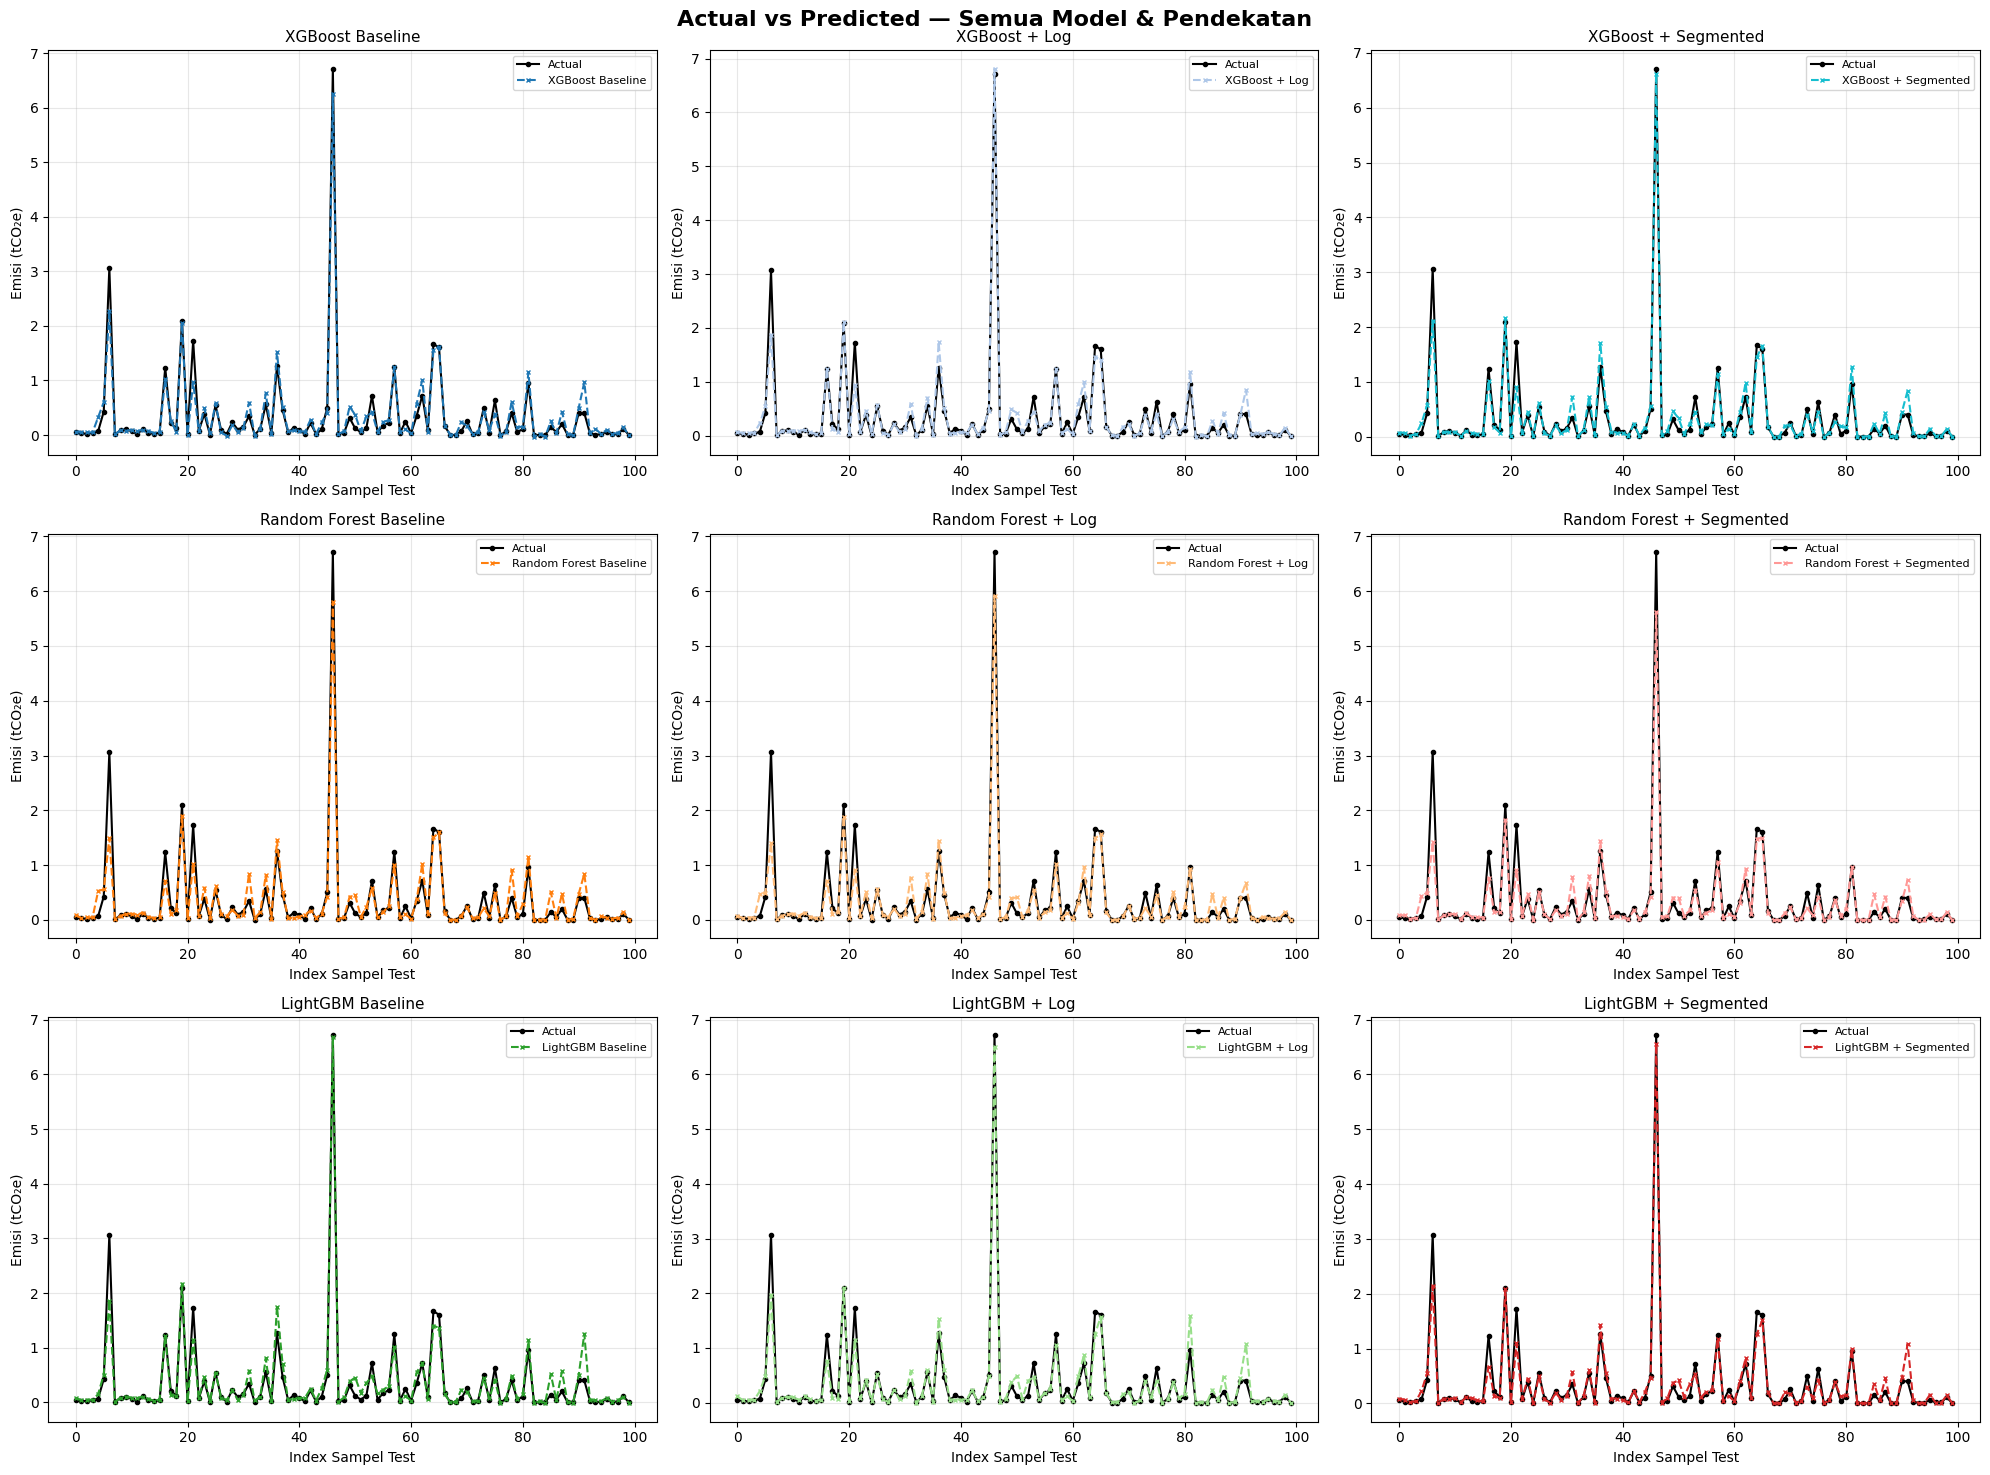

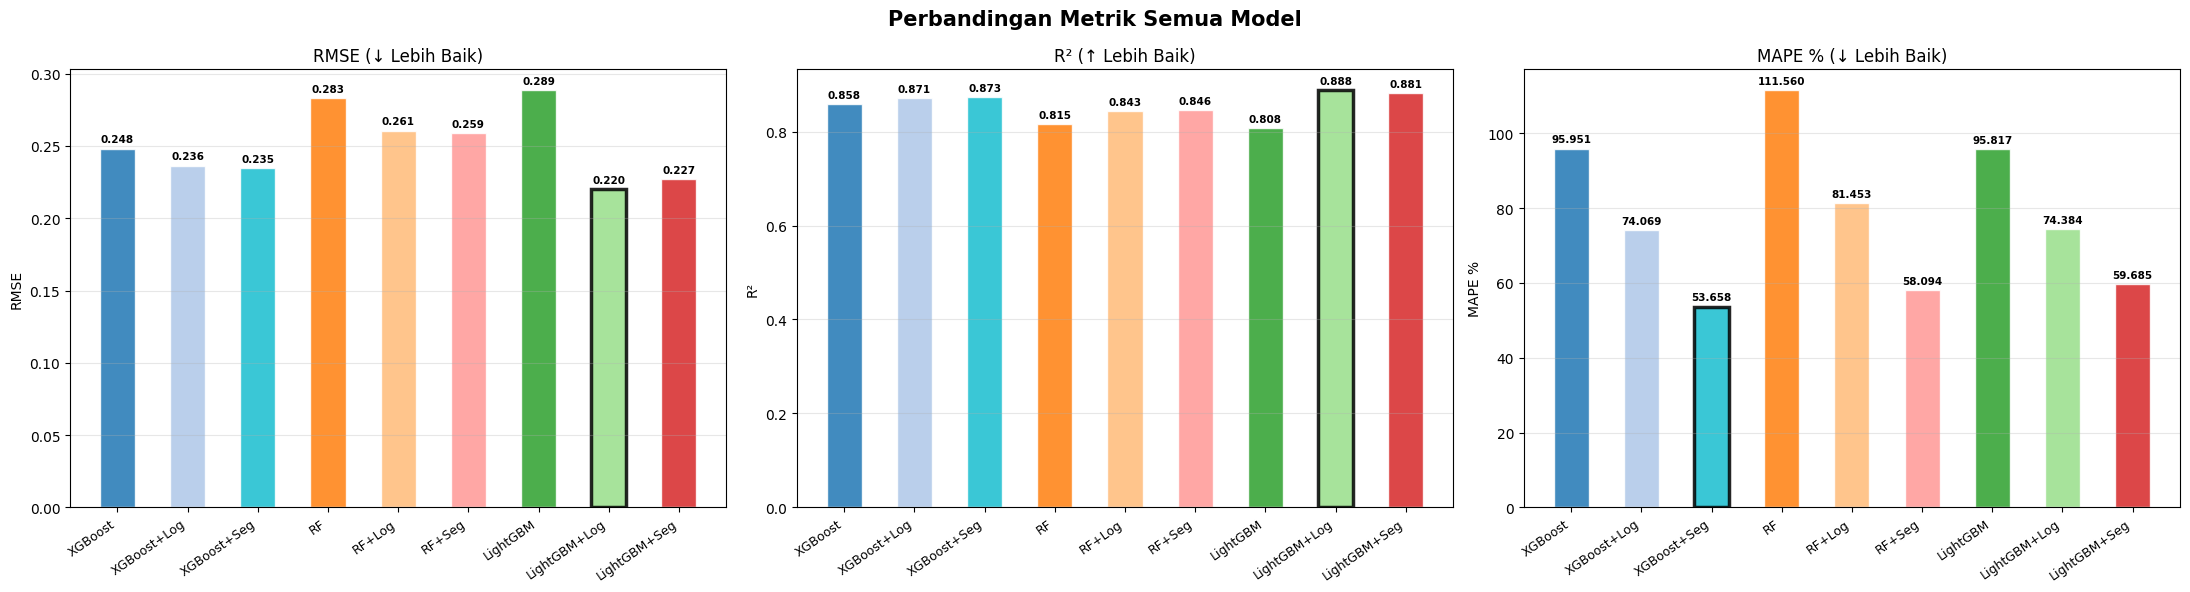

In [13]:
# visualisasi actual vs predicted dan perbandingan metrik
fig, axes = plt.subplots(3, 3, figsize=(20, 15))
fig.suptitle('Actual vs Predicted — Semua Model & Pendekatan', fontsize=16, fontweight='bold')

plot_configs = [
    (y_pred_xgb,      'XGBoost Baseline',         '#1f77b4', axes[0][0]),
    (y_pred_xgb_log,  'XGBoost + Log',             '#aec7e8', axes[0][1]),
    (y_pred_xgb_seg,  'XGBoost + Segmented',       '#17becf', axes[0][2]),
    (y_pred_rf,       'Random Forest Baseline',    '#ff7f0e', axes[1][0]),
    (y_pred_rf_log,   'Random Forest + Log',       '#ffbb78', axes[1][1]),
    (y_pred_rf_seg,   'Random Forest + Segmented', '#ff9896', axes[1][2]),
    (y_pred_lgb,      'LightGBM Baseline',         '#2ca02c', axes[2][0]),
    (y_pred_log,      'LightGBM + Log',            '#98df8a', axes[2][1]),
    (y_pred_segmented,'LightGBM + Segmented',      '#d62728', axes[2][2]),
]

for y_pred, title, color, ax in plot_configs:
    ax.plot(y_test.values[:100], label='Actual', marker='o', linewidth=1.5, color='black', markersize=3)
    ax.plot(y_pred[:100], label=title, marker='x', linestyle='--', color=color, linewidth=1.5, markersize=3)
    ax.set_title(title, fontsize=11)
    ax.set_ylabel('Emisi (tCO₂e)')
    ax.set_xlabel('Index Sampel Test')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

models_all = ['XGBoost','XGBoost+Log','XGBoost+Seg','RF','RF+Log','RF+Seg','LightGBM','LightGBM+Log','LightGBM+Seg']
rmses_all  = [rmse_xgb, rmse_xgb_log, rmse_xgb_seg, rmse_rf, rmse_rf_log, rmse_rf_seg, rmse_lgb, rmse_log, rmse_seg]
r2s_all    = [r2_xgb,   r2_xgb_log,   r2_xgb_seg,   r2_rf,  r2_rf_log,  r2_rf_seg,  r2_lgb,  r2_log,  r2_seg]
mapes_all  = [mape_xgb, mape_xgb_log, mape_xgb_seg, mape_rf, mape_rf_log, mape_rf_seg, mape_lgb, mape_log, mape_seg]
colors_all = ['#1f77b4','#aec7e8','#17becf','#ff7f0e','#ffbb78','#ff9896','#2ca02c','#98df8a','#d62728']

x = np.arange(len(models_all))
fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.suptitle('Perbandingan Metrik Semua Model', fontsize=15, fontweight='bold')

for i, (vals, title, ylabel, better) in enumerate([
    (rmses_all, 'RMSE (↓ Lebih Baik)', 'RMSE', 'min'),
    (r2s_all,   'R² (↑ Lebih Baik)',   'R²',   'max'),
    (mapes_all, 'MAPE % (↓ Lebih Baik)','MAPE %','min'),
]):
    bars = axes[i].bar(x, vals, 0.5, color=colors_all, alpha=0.85, edgecolor='white')
    best_idx = np.argmin(vals) if better == 'min' else np.argmax(vals)
    bars[best_idx].set_edgecolor('black')
    bars[best_idx].set_linewidth(2.5)
    axes[i].set_title(title, fontsize=12)
    axes[i].set_ylabel(ylabel)
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(models_all, rotation=35, ha='right', fontsize=9)
    axes[i].grid(True, axis='y', alpha=0.3)
    for j, v in enumerate(vals):
        axes[i].text(j, v + max(vals)*0.01, f'{v:.3f}', ha='center', va='bottom', fontsize=7.5, fontweight='bold')

plt.tight_layout()
plt.show()

In [14]:
# prediksi emisi bulan berikutnya per supplier
def predict_next_month(agg_df, lgb_small, lgb_large, feature_cols, threshold=THRESHOLD):
    last_data = agg_df.sort_values('date').groupby(['plant_id', 'supplier']).last().reset_index()

    lag_cols = ['emission_lag_1', 'emission_lag_2', 'emission_lag_3', 'freq_lag_1', 'freq_lag_2']
    missing_mask = last_data[lag_cols].isnull().any(axis=1)
    global_mean = agg_df['total_emission'].mean()

    last_data.loc[missing_mask, 'emission_lag_1'] = last_data.loc[missing_mask, 'total_emission'].fillna(global_mean)
    last_data.loc[missing_mask, 'emission_lag_2'] = global_mean
    last_data.loc[missing_mask, 'emission_lag_3'] = global_mean
    last_data.loc[missing_mask, 'freq_lag_1'] = last_data.loc[missing_mask, 'freq'].fillna(1)
    last_data.loc[missing_mask, 'freq_lag_2'] = last_data.loc[missing_mask, 'freq'].fillna(1)

    last_date  = agg_df['date'].max()
    next_date  = last_date + pd.DateOffset(months=1)
    next_month = next_date.month

    pred_df = last_data.copy()
    pred_df['date'] = next_date
    pred_df['year'] = next_date.year

    pred_df['emission_lag_3'] = pred_df['emission_lag_2']
    pred_df['emission_lag_2'] = pred_df['emission_lag_1']
    pred_df['emission_lag_1'] = pred_df['total_emission']
    pred_df['freq_lag_2']     = pred_df['freq_lag_1']
    pred_df['freq_lag_1']     = pred_df['freq']

    pred_df['emission_rolling_mean_3'] = pred_df[['emission_lag_1','emission_lag_2','emission_lag_3']].mean(axis=1)
    pred_df['emission_rolling_std_3']  = pred_df[['emission_lag_1','emission_lag_2','emission_lag_3']].std(axis=1).fillna(0)

    month_cols = [c for c in pred_df.columns if c.startswith('month_')]
    pred_df[month_cols] = 0
    if f'month_{next_month}' in pred_df.columns:
        pred_df[f'month_{next_month}'] = 1

    X_pred     = pred_df[feature_cols]
    mask_small = pred_df['total_emission'] <= threshold
    mask_large = ~mask_small

    pred_df['predicted_emission'] = 0.0
    if mask_small.any():
        pred_df.loc[mask_small, 'predicted_emission'] = lgb_small.predict(X_pred[mask_small])
    if mask_large.any():
        pred_df.loc[mask_large, 'predicted_emission'] = np.expm1(lgb_large.predict(X_pred[mask_large]))

    pred_df['predicted_emission'] = pred_df['predicted_emission'].clip(lower=0).round(4)
    pred_df['is_new_supplier']    = missing_mask.values

    result = pred_df[['plant_id', 'supplier', 'predicted_emission', 'is_new_supplier']].copy()
    result['prediction_month'] = next_date.strftime('%B %Y')
    result['based_on']         = last_date.strftime('%B %Y')
    result = result.sort_values('predicted_emission', ascending=False).reset_index(drop=True)

    return result

result = predict_next_month(agg_df, lgb_small, lgb_large, feature_cols)

total_predicted = result['predicted_emission'].sum().round(4)
print(f"\n📊 Total Prediksi Emisi Bulan {result['prediction_month'].iloc[0]}: {total_predicted} tCO₂e")
print(f"   (Berdasarkan data: {result['based_on'].iloc[0]})\n")

print("Prediksi per Supplier (Top 20):")
result.head(20)


📊 Total Prediksi Emisi Bulan January 2025: 61.5433 tCO₂e
   (Berdasarkan data: December 2024)

Prediksi per Supplier (Top 20):


,plant_id,supplier,predicted_emission,is_new_supplier,prediction_month,based_on
0,2,PT. NSA,3.7945,False,January 2025,December 2024
1,1,CM,3.2961,False,January 2025,December 2024
2,2,PT. BMI,1.5211,False,January 2025,December 2024
3,2,JUSPT,1.3679,False,January 2025,December 2024
4,1,PT. SMIP,1.2480,False,January 2025,December 2024
5,2,BSA,1.2315,False,January 2025,December 2024
6,1,MP,1.1462,False,January 2025,December 2024
7,2,PT. E,1.1364,False,January 2025,December 2024
8,2,PT. VG,1.1170,False,January 2025,December 2024
9,1,SFS,1.0332,False,January 2025,December 2024


In [ ]:
import lightgbm as lgb

# Export lgb_small model
lgb_small.save_model('lgbm_small_model.json')
print("LightGBM 'lgb_small' model saved to lgbm_small_model.json")

# Export lgb_large model
lgb_large.save_model('lgbm_large_model.json')
print("LightGBM 'lgb_large' model saved to lgbm_large_model.json")